### Global Superstore dataset is a comprehensive dataset containing information about sales and orders in a global superstore. It is a valuable resource for data analysis and visualization tasks.

This dataset can be used for various data analysis tasks, including understanding sales patterns, customer behavior, and profitability in the context of a global superstore.

Here is a description of the columns in the dataset:

* category: The category of products sold in the superstore.
* city: The city where the order was placed.
* country: The country in which the superstore is located.
* customer_id: A unique identifier for each customer.
* customer_name: The name of the customer who placed the order.
* discount: The discount applied to the order.
* market: The market or region where the superstore operates.
* ji_lu_shu: An unknown or unspecified column.
* order_date: The date when the order was placed.
* order_id: A unique identifier for each order.
* order_priority: The priority level of the order.
* product_id: A unique identifier for each product.
* product_name: The name of the product.
* profit: The profit generated from the order.
* quantity: The quantity of products ordered.
* region: The region where the order was placed.
* row_id: A unique identifier for each row in the dataset.
* sales: The total sales amount for the order.
* segment: The customer segment (e.g., consumer, corporate, or home office).
* ship_date: The date when the order was shipped.
* ship_mode: The shipping mode used for the order.
* shipping_cost: The cost of shipping for the order.
* state: The state or region within the country.
* sub_category: The sub-category of products within the main category.
* year: The year in which the order was placed.
* market2: Another column related to market information.
* weeknum: The week number when the order was placed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## Layer 0 — Data preparation

1. Removing unnecessary columns
2. Renaming columns
3. Type conversion
4. Handling null values
5. Removing duplicates

In [2]:
df = pd.read_csv(r"D:\Downloads\superstore.csv")

df.info()

display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer.ID     51290 non-null  str    
 4   Customer.Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  str    
 9   Order.ID        51290 non-null  str    
 10  Order.Priority  51290 non-null  str    
 11  Product.ID      51290 non-null  str    
 12  Product.Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null  int64  
 1

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [3]:
df.isna().sum(axis=0)

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [4]:
df.duplicated().value_counts()
df = df.drop_duplicates()

记录数 - Number of Records, just a line counter. And I do not need Customer.Name because I already have Customer.ID, so I will drop both.

Order.Date, Ship.Date does not match the data type - need to fix it.

Also for SQL queries I need to rename columns from Order.Date to order_date. This will improve readability

In [5]:
df = df.drop(columns=['记录数', 'Customer.Name'])

In [6]:
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])

df['Month'] = df['Order.Date'].dt.strftime('%Y-%m')

df.columns = df.columns.str.replace('.', '_', regex=False).str.lower()

## Layer 1 — SQL (SQLite in Python)

1. Top 10 countries by revenue
2. Profitability by category and market
3. Which customer segment generates the most profit
4. Month-over-month sales trends

In [7]:
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, if_exists='replace', index=False)

51290

In [8]:
top_countries_by_revenue = '''
select
    country,
    round(sum(sales) ,2) as total_revenue
from sales
group by country
order by total_revenue desc
limit 10;
'''

result_1 = pd.read_sql(top_countries_by_revenue, conn)
result_1

,country,total_revenue
0,United States,2297354.0
1,Australia,925257.0
2,France,858930.0
3,China,700591.0
4,Germany,628857.0
5,Mexico,622620.0
6,India,589664.0
7,United Kingdom,528570.0
8,Indonesia,404887.0
9,Brazil,361098.0


It is clear that the United States is the absolute leader in terms of revenue, with total_revenue of 2,297,354; Australia and France are in second and third place with 925,257 and 858,930 respectively. Rounding out the top 10 are Brazil (361,098) and Indonesia (404,887).

In [9]:
profit_by_category_and_market = '''
select
    category,
    market,
    round(sum(profit),2) as total_profit,
    round(sum(profit) * 100 / sum(sum(profit)) over(), 2) as profit_share
from sales
group by category, market
order by sum(profit) desc

'''
result_2 = pd.read_sql(profit_by_category_and_market, conn)
result_2

,category,market,total_profit,profit_share
0,Technology,APAC,204593.86,13.94
1,Office Supplies,EU,159706.94,10.88
2,Technology,US,145454.95,9.91
3,Technology,EU,144272.66,9.83
4,Furniture,APAC,125896.15,8.58
5,Office Supplies,US,122490.80,8.35
6,Office Supplies,APAC,105510.04,7.19
7,Technology,LATAM,100586.72,6.85
8,Office Supplies,LATAM,79459.07,5.41
9,Furniture,EU,68850.14,4.69


The majority of revenue is generated in the Technology category, particularly in APAC and developed markets (US, EU). The Technology sector is the leading category. Meanwhile, Furniture is a weak category.
Developed markets such as the US, EU and APAC are the main source of profit. Emerging markets (LATAM, Africa, Canada) are lagging behind, and there are also specific demand patterns: demand for Furniture is higher in APAC than in the US; demand for Technology in Canada is very low. This indicates either growth potential or the need to review strategies in these regions.

In [10]:
profit_by_customer_segment = '''
select segment,
    round(sum(profit),2) as total_profit,
    round(sum(sales), 2) as total_revenue,
    count(distinct order_id) as total_orders,
    round(sum(sales) / count(distinct order_id), 2) as avg_order_value
from sales
group by segment
order by sum(profit) desc;
'''

result_3 = pd.read_sql(profit_by_customer_segment, conn)
result_3

,segment,total_profit,total_revenue,total_orders,avg_order_value
0,Consumer,749239.78,6508141.0,13104,496.0
1,Corporate,441208.33,3824808.0,7673,498.0
2,Home Office,277009.18,2309956.0,4687,492.0


The Consumer segment is the main driver of profit and also accounts for the largest volume of orders. The Corporate segment ranks second; whilst the volume of orders is lower, the average order value is 2 points higher, which may indicate a higher-quality customer base. Home Office is the weakest segment across all metrics. This may be due to a smaller customer base or lower engagement. Strategies for this segment need to be reviewed, or priorities reassessed if its contribution remains insignificant.

In [11]:
sales_trends_dynamic = '''
select
    month,
    count(distinct order_id) as order_count,
    lag(round(sum(sales), 2)) over(order by month) as prev_revenue,
    lag(round(sum(profit), 2)) over(order by month) as prev_profit,
    round(sum(sales), 2) as curr_revenue,
    round(sum(profit), 2) as curr_profit,
    round(sum(sum(sales)) over(order by month), 2) as running_total_revenue,
    round(sum(sum(profit)) over(order by month), 2) as running_total_profit,
    round(
        (sum(sales) - lag(sum(sales)) over(order by month)) * 100.0
        / nullif(lag(sum(sales)) over(order by month), 0)
    , 2) as mom_growth_pct
from sales
group by month
order by month asc
'''

result_4 = pd.read_sql(sales_trends_dynamic, conn)
result_4


,month,order_count,prev_revenue,prev_profit,curr_revenue,curr_profit,running_total_revenue,running_total_profit,mom_growth_pct
0,2011-01,216,NaN,NaN,98902.0,8321.80,98902.0,8321.80,NaN
1,2011-02,183,98902.0,8321.80,91152.0,12417.91,190054.0,20739.71,-7.84
2,2011-03,277,91152.0,12417.91,145726.0,15303.57,335780.0,36043.28,59.87
3,2011-04,267,145726.0,15303.57,116927.0,12902.32,452707.0,48945.60,-19.76
4,2011-05,295,116927.0,12902.32,146762.0,12183.83,599469.0,61129.43,25.52
5,2011-06,468,146762.0,12183.83,215214.0,23415.25,814683.0,84544.68,46.64
6,2011-07,250,215214.0,23415.25,115518.0,5585.00,930201.0,90129.68,-46.32
7,2011-08,443,115518.0,5585.00,207570.0,23713.67,1137771.0,113843.35,79.69
8,2011-09,527,207570.0,23713.67,290230.0,35776.88,1428001.0,149620.23,39.82
9,2011-10,401,290230.0,35776.88,199070.0,25963.42,1627071.0,175583.65,-31.41


In [12]:
first = result_4['curr_revenue'].iloc[0]
last = result_4['curr_revenue'].iloc[-1]
total_growth = round((last - first) / first * 100.0, 2)
print(f"Total revenue growth (2011-2014): {total_growth}%")

avg_mom = result_4['mom_growth_pct'].dropna().mean().round(2)
print(f"Average MoM growth: {avg_mom}%")

best = result_4.loc[result_4['mom_growth_pct'].idxmax()]
worst = result_4.loc[result_4['mom_growth_pct'].idxmin()]
print(f"Best month: {best['month']} ({best['mom_growth_pct']}%)")
print(f"Worst month: {worst['month']} ({worst['mom_growth_pct']}%)")

Total revenue growth (2011-2014): 408.74%
Average MoM growth: 10.23%
Best month: 2012-08 (108.72%)
Worst month: 2012-01 (-59.34%)


An analysis of sales trends shows steady revenue growth between 2011 and 2014. Despite significant month-to-month fluctuations, the overall trend remains positive: revenue increased approximately fourfold over this period. The average monthly growth rate for sales (revenue) stands at 10.23%. However, high volatility is observed: for example, the best growth figure was recorded in August 2012 at 108.72%, whilst the worst month was January 2012 with a result of -59.34%. These are excellent growth figures for the company and indicate that most of the company’s strategies are proving successful.
Seasonality is also evident: strong months are followed by a pullback, which may be linked to the cyclical nature of demand and promotional activity.
Overall, the business is showing growth, but a more detailed analysis of factors relating to seasonality, marketing and external conditions is required.

# Overall



The company’s main revenue is generated in developed markets, primarily in the US (with revenue of 2,297,354), Australia (925,257) and France (858,930), which significantly outstrips other countries. At the same time, emerging markets are showing weaker results. Specific demand patterns are observed in certain regions, indicating potential growth areas.
In terms of customer segments, the key driver is the Consumer segment, which generates both the highest revenue and the largest order volume. Although the Corporate segment shows a lower order volume, the average order value is higher, which may indicate a higher-quality audience. The Home Office segment lags significantly across all metrics, requiring a review of its development strategy.
The Technology category makes the main contribution to profit, particularly in the developed markets of APAC, the US and the EU. At the same time, Furniture is the weakest category. Specific demand patterns can be observed: a weak Technology market in Canada, and demand for furniture in the Asia-Pacific region is higher than in the US. This may indicate a need to adapt the product strategy in these markets to local characteristics.
The business has shown steady revenue growth between 2011 and 2014. Despite significant monthly fluctuations, the overall trend remains positive: revenue for this period increased approximately fourfold, with an average monthly growth rate of 10.23%. However, this growth is accompanied by high volatility and pronounced seasonality, indicating unstable demand.
The company is in a phase of active growth, though this is accompanied by imbalances across segments, categories and regions, indicating potential for further development.

# Layer 2 — Python/Pandas

1. RFM customer analysis — segmentation into Champions, Loyal, At Risk, etc.
2. Discount analysis — how the size of the discount affects profit
3. Visualisations using matplotlib/seaborn

## RFM Segmentation

1. Recency - how many days ago the last purchase was made (the fewer, the better)
2. Frequency  -  how many orders have been placed (the more, the better)
3. Monetary  - how much money has been spent (the more, the better)

In [21]:
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('sales', 'sum')
).reset_index()

print(rfm.head())
print(rfm.describe())

  customer_id  recency  frequency  monetary
0   AA-103151        9          5      1445
1   AA-103152       14          7      6105
2   AA-103153      695          2       633
3   AA-103154      185          5      5565
4   AA-103751        7          4      2407
           recency    frequency      monetary
count  4873.000000  4873.000000   4873.000000
mean    207.422943     5.284835   2594.480813
std     254.526205     2.857330   2465.921576
min       1.000000     1.000000      2.000000
25%      42.000000     3.000000    728.000000
50%     110.000000     5.000000   1894.000000
75%     269.000000     7.000000   3763.000000
max    1460.000000    18.000000  25042.000000


qcut divides the data into four equal parts (quartiles). For recency, the fewer the days the higher the score (so [4,3,2,1]). For frequency and monetary, the opposite ([1,2,3,4])

In [23]:
rfm['r_score'] = pd.qcut(rfm['recency'], q=4, labels=[4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['m_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1,2,3,4])

In [24]:
def segment(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 3 and f < 3:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(segment, axis=1)
print(rfm['segment'].value_counts())

segment
Lost                  1631
Loyal                 1127
Potential Loyalist     806
At Risk                801
Champions              508
Name: count, dtype: int64


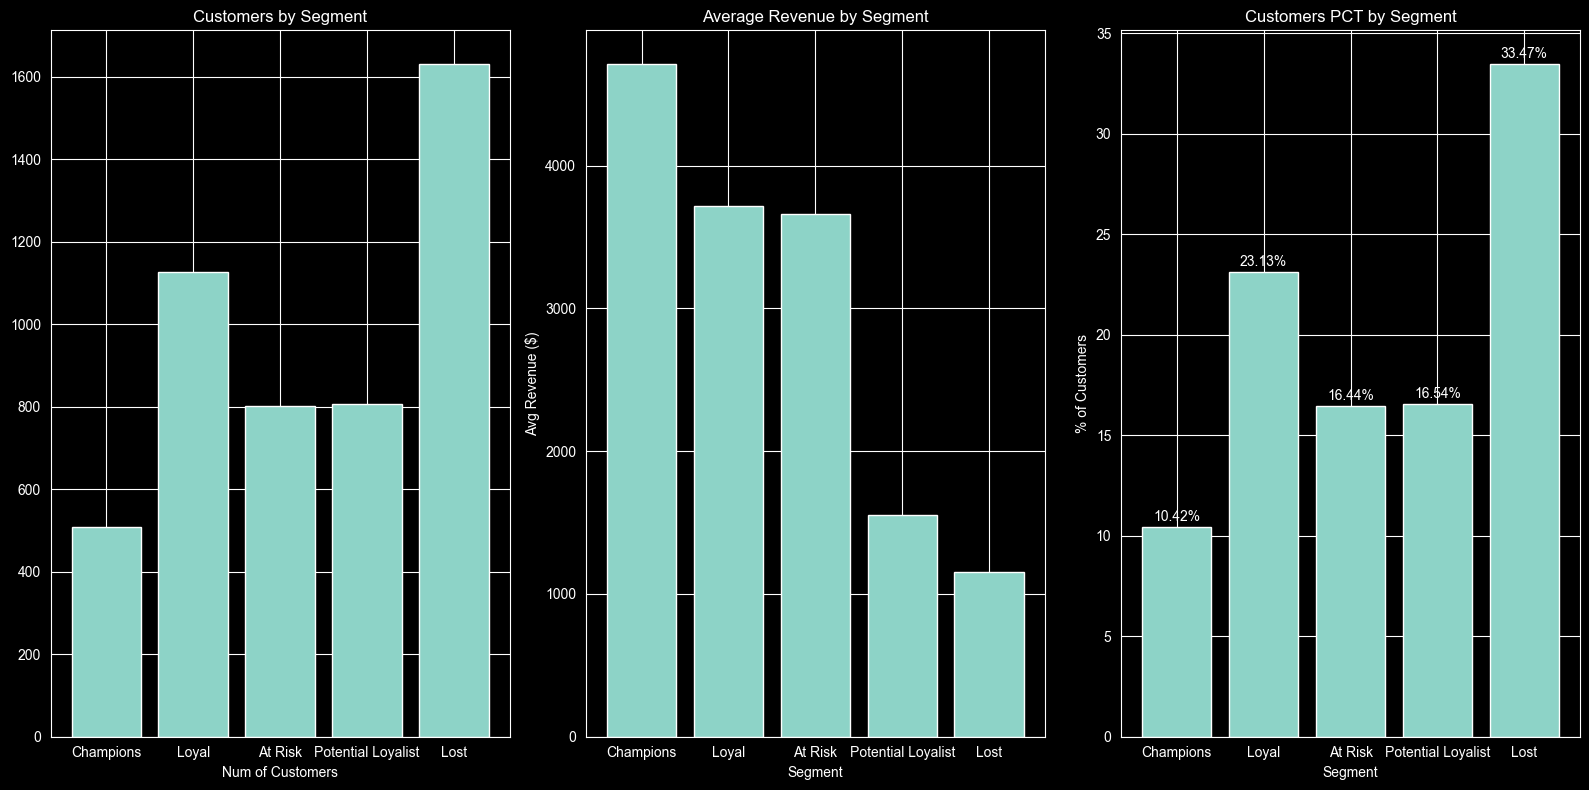

           segment  customers  customer_pct  avg_revenue  avg_recency
         Champions        508         10.42  4711.129921    20.163386
             Loyal       1127         23.13  3716.405501    56.262644
           At Risk        801         16.44  3662.334582   237.605493
Potential Loyalist        806         16.54  1549.490074    47.306452
              Lost       1631         33.47  1151.957695   434.500307


In [62]:
seg_summary = rfm.groupby('segment').agg(
    customers = ('customer_id', 'count'),
    avg_revenue = ('monetary', 'mean'),
    avg_recency = ('recency', 'mean'),
).reset_index().sort_values('avg_revenue', ascending=False)

seg_summary['customer_pct'] = (seg_summary['customers'] * 100 / seg_summary['customers'].sum()).round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

axes[0].bar(seg_summary['segment'], seg_summary['customers'])
axes[0].set_title('Customers by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_xlabel('Num of Customers')

axes[1].bar(seg_summary['segment'], seg_summary['avg_revenue'])
axes[1].set_title('Average Revenue by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg Revenue ($)')

axes[2].bar(seg_summary['segment'], seg_summary['customer_pct'])
axes[2].set_title('Customers PCT by Segment')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('% of Customers')

for bar, pct in zip(axes[2].patches, seg_summary['customer_pct']):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{pct}%',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

print(seg_summary[['segment', 'customers', 'customer_pct', 'avg_revenue', 'avg_recency']].to_string(index=False))

Most customers fall into the Lost category - they are no longer active and generate minimal revenue. Champions make up 10% of the customer base, yet generate four times as much revenue per customer. The priority is to retain the At Risk segment, which has a high average spend (avg_revenue) of approximately 3,662 dollars comparable to the Loyal segment at 3,716 dollars but is losing activity.

## Discount Analysis

In [39]:
print(df['discount'].value_counts().head(10).sort_index())

discount
0.00    29009
0.10     4068
0.15      541
0.17      735
0.20     4998
0.40     3177
0.47      725
0.50     1633
0.60     2006
0.70     1786
Name: count, dtype: int64


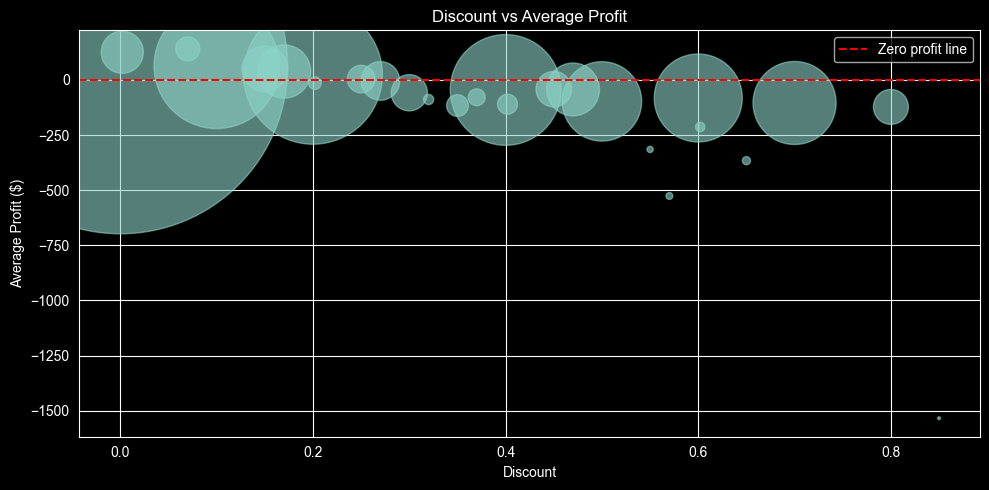

In [41]:
discount_analysis = df.groupby('discount').agg(
    avg_profit=('profit', 'mean'),
    avg_sales=('sales', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

plt.figure(figsize=(10, 5))
plt.scatter(discount_analysis['discount'], discount_analysis['avg_profit'],
            s=discount_analysis['order_count'] * 2, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', label='Zero profit line')
plt.title('Discount vs Average Profit')
plt.xlabel('Discount')
plt.ylabel('Average Profit ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
print(discount_analysis[['discount', 'avg_profit', 'order_count']].sort_values(by = ['discount', 'avg_profit'], ascending=True))

    discount   avg_profit  order_count
0      0.000    61.039514        29009
1      0.002   125.762649          461
2      0.070   140.990022          150
3      0.100    63.683426         4068
4      0.150    50.602409          541
5      0.170    38.317107          735
6      0.200    23.552594         4998
7      0.202   -14.518847           41
8      0.250     4.043371          198
9      0.270    -4.317213          388
10     0.300   -57.899557          340
11     0.320   -88.560656           27
12     0.350  -116.144693          122
13     0.370   -78.462191           74
14     0.400   -45.246603         3177
15     0.402  -109.908138          104
16     0.450   -41.610973          327
17     0.470   -42.982420          725
18     0.500   -97.140158         1633
19     0.550  -315.067200           10
20     0.570  -526.129000           12
21     0.600   -81.732147         2006
22     0.602  -213.279085           23
23     0.650  -365.997971           17
24     0.700  -104.339576

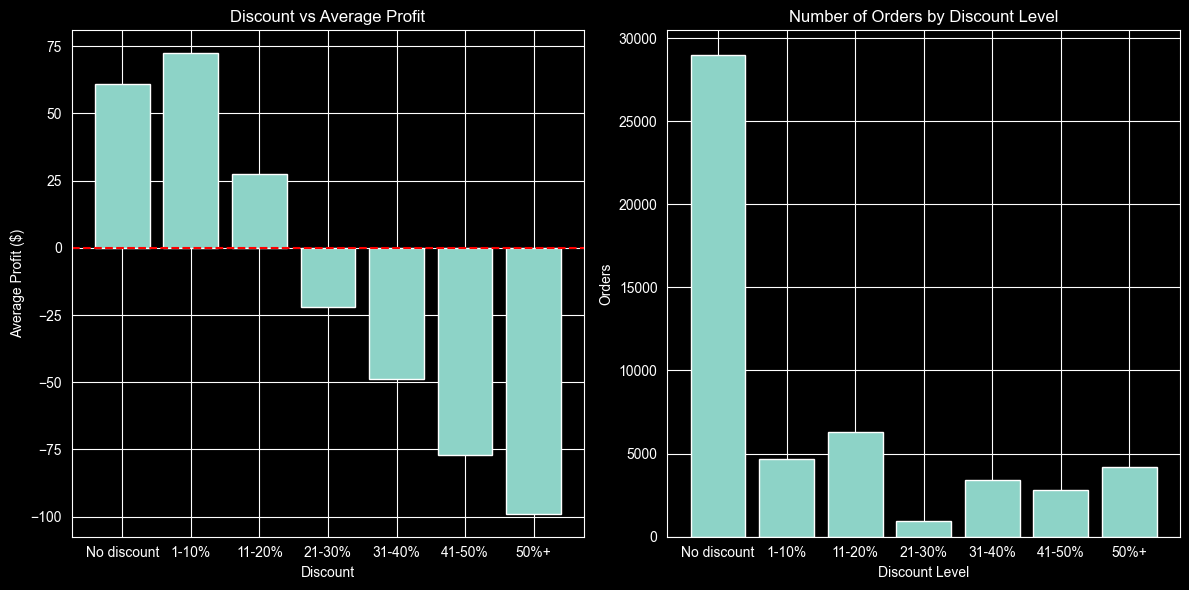

In [50]:
df['discount_bucket'] = pd.cut(
    df['discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
    labels=['No discount', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '50%+']
)

bucket_analysis = df.groupby('discount_bucket').agg(
    avg_profit=('profit', 'mean'),
    avg_sales=('sales', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(bucket_analysis['discount_bucket'], bucket_analysis['avg_profit'])
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Discount vs Average Profit')
axes[0].set_xlabel('Discount')
axes[0].set_ylabel('Average Profit ($)')

axes[1].bar(bucket_analysis['discount_bucket'], bucket_analysis['order_count'])
axes[1].set_title('Number of Orders by Discount Level')
axes[1].set_xlabel('Discount Level')
axes[1].set_ylabel('Orders')

plt.tight_layout()
plt.show()

Analysis shows that approximately 38,000 orders with discounts of up to 20% remain profitable. From 21% onwards, every order generates a loss. The 41%+ bracket is particularly critical: approximately 7,500 orders with an average loss of 80–100 dollars per order. Recommendation: limit the maximum discount to 20% and review promotional offers with discounts above this threshold.

# Overall



In [59]:
df_rfm = df.merge(
    rfm[['customer_id', 'segment']].rename(columns={'segment': 'rfm_segment'}),
    on = 'customer_id'
)

print(df_rfm.columns.tolist())
print(df_rfm.shape)

['category', 'city', 'country', 'customer_id', 'discount', 'market', 'order_date', 'order_id', 'order_priority', 'product_id', 'product_name', 'profit', 'quantity', 'region', 'row_id', 'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost', 'state', 'sub_category', 'year', 'market2', 'weeknum', 'month', 'discount_bucket', 'rfm_segment']
(51290, 28)


          rfm_segment  avg_discount  avg_profit  order_count
2                Lost      0.151372   21.685260         8934
1           Champions      0.144028   30.826619         9440
4  Potential Loyalist      0.143619   28.441036         5568
3               Loyal      0.141124   29.300168        16034
0             At Risk      0.137467   31.338104        11314


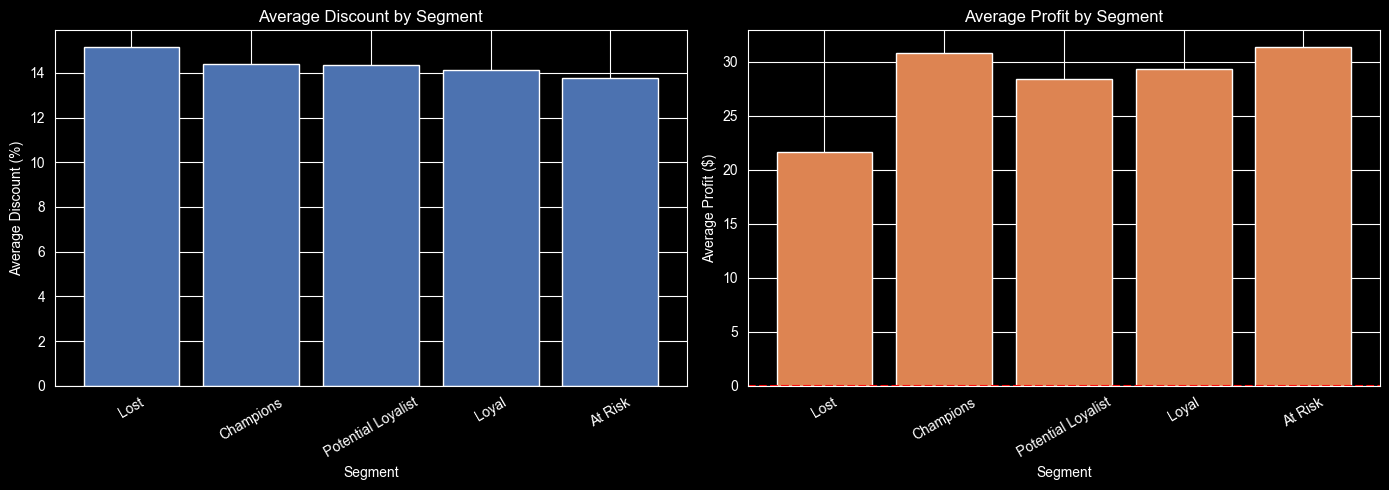

In [61]:
seg_discount = df_rfm.groupby('rfm_segment').agg(
    avg_discount=('discount', 'mean'),
    avg_profit=('profit', 'mean'),
    order_count=('order_id', 'count')
).reset_index().sort_values('avg_discount', ascending=False)

print(seg_discount)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(seg_discount['rfm_segment'], seg_discount['avg_discount'] * 100, color='#4C72B0')
axes[0].set_title('Average Discount by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Average Discount (%)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(seg_discount['rfm_segment'], seg_discount['avg_profit'], color='#DD8452')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Average Profit by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Average Profit ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

The company is losing profit on two fronts: aggressive discounts (40%+) are eroding margins on over 7,500 orders. Although the majority of customers belong to the Lost segment (already inactive), the main risk lies with the At Risk segment — average revenue is close to that of the Loyal segment (3,662 versus 3,716), and there is a high probability of these customers moving into the Lost segment. Champions remains the most profitable segment, whilst customers in this category purchase with roughly the same average discount (+-14%) as the Lost segment (+-15%). Discounts do not retain customers or convert them into loyal buyers.

# Layer 3 — Power BI

1. KPI cards: revenue, profit, number of orders
2. Sales by market (world map)
3. Year-on-year trends
4. Top categories by profit
5. DAX metric: Profit Margin %

In [63]:
df.to_csv('superstore_clean.csv', index=False)

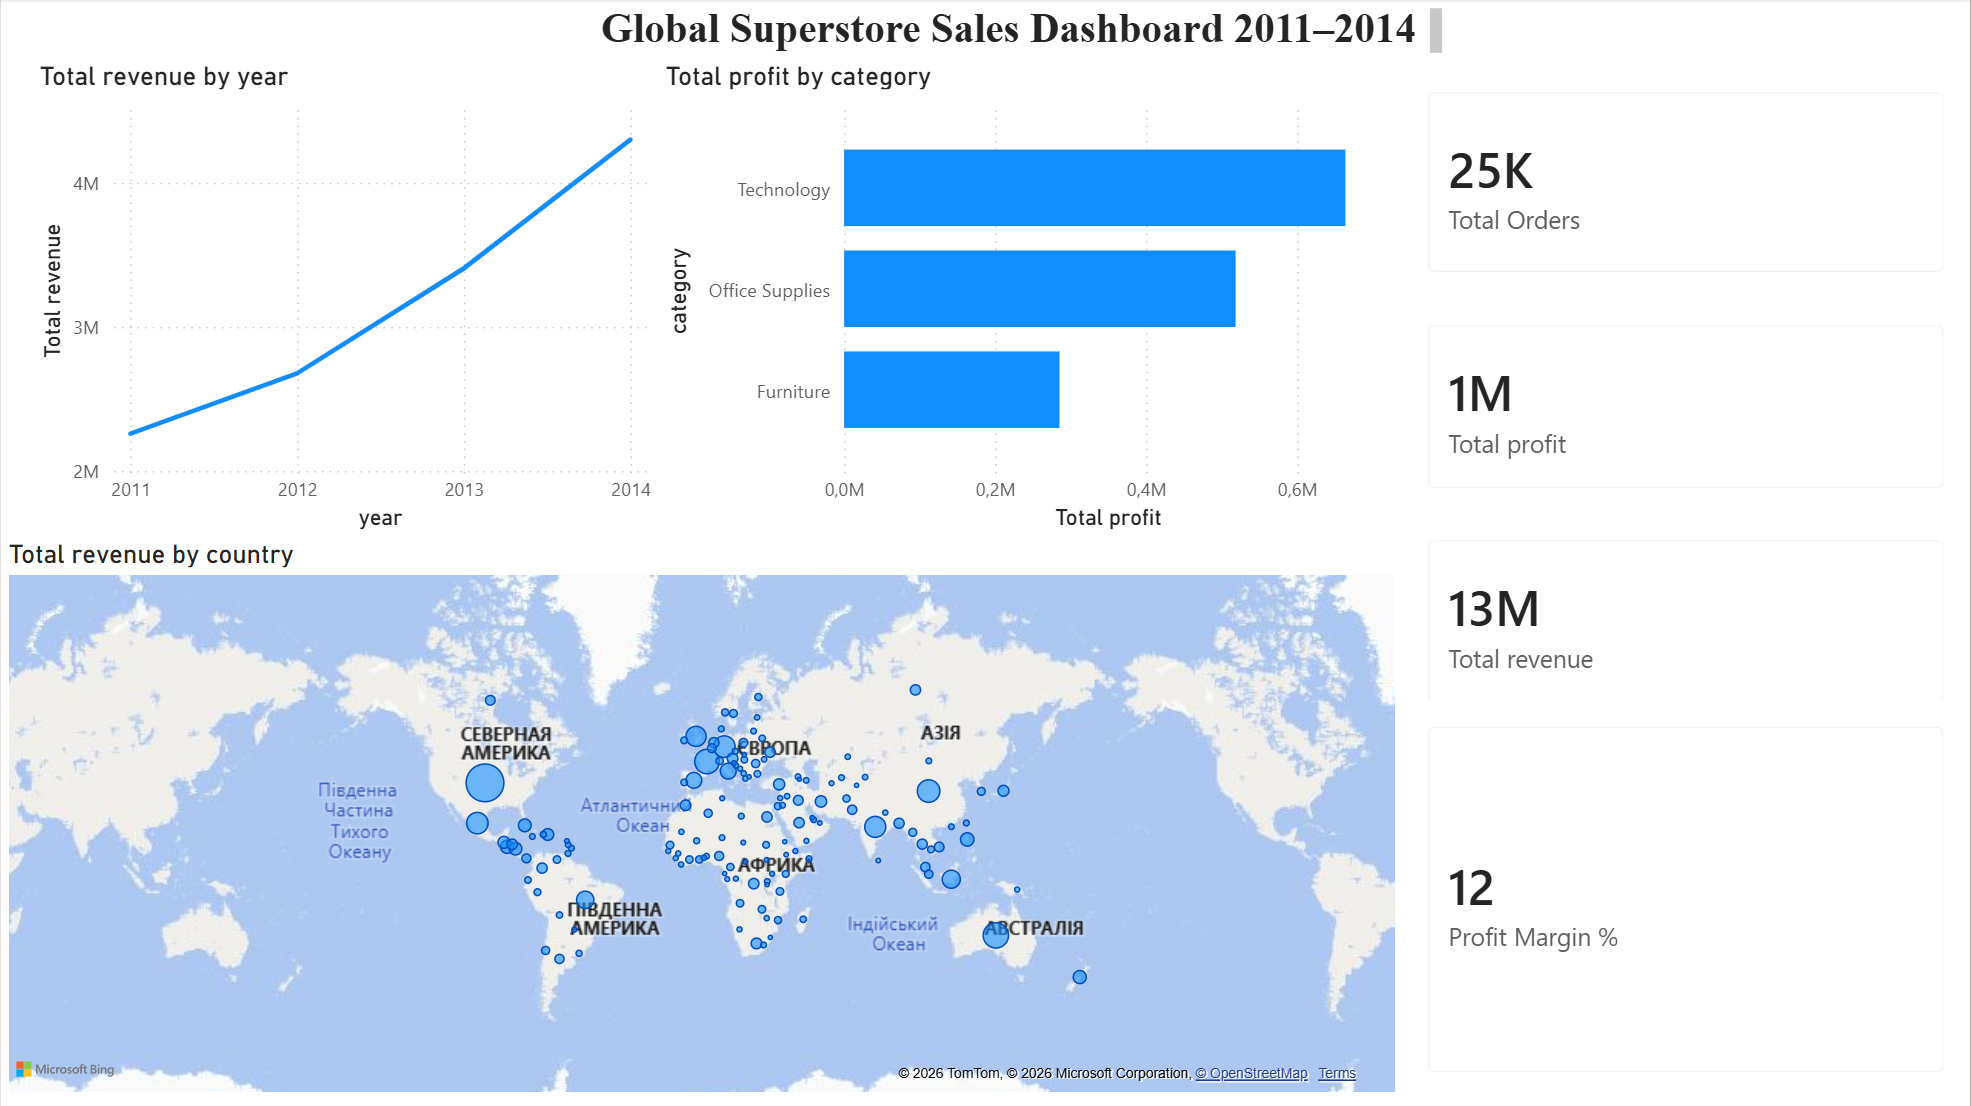
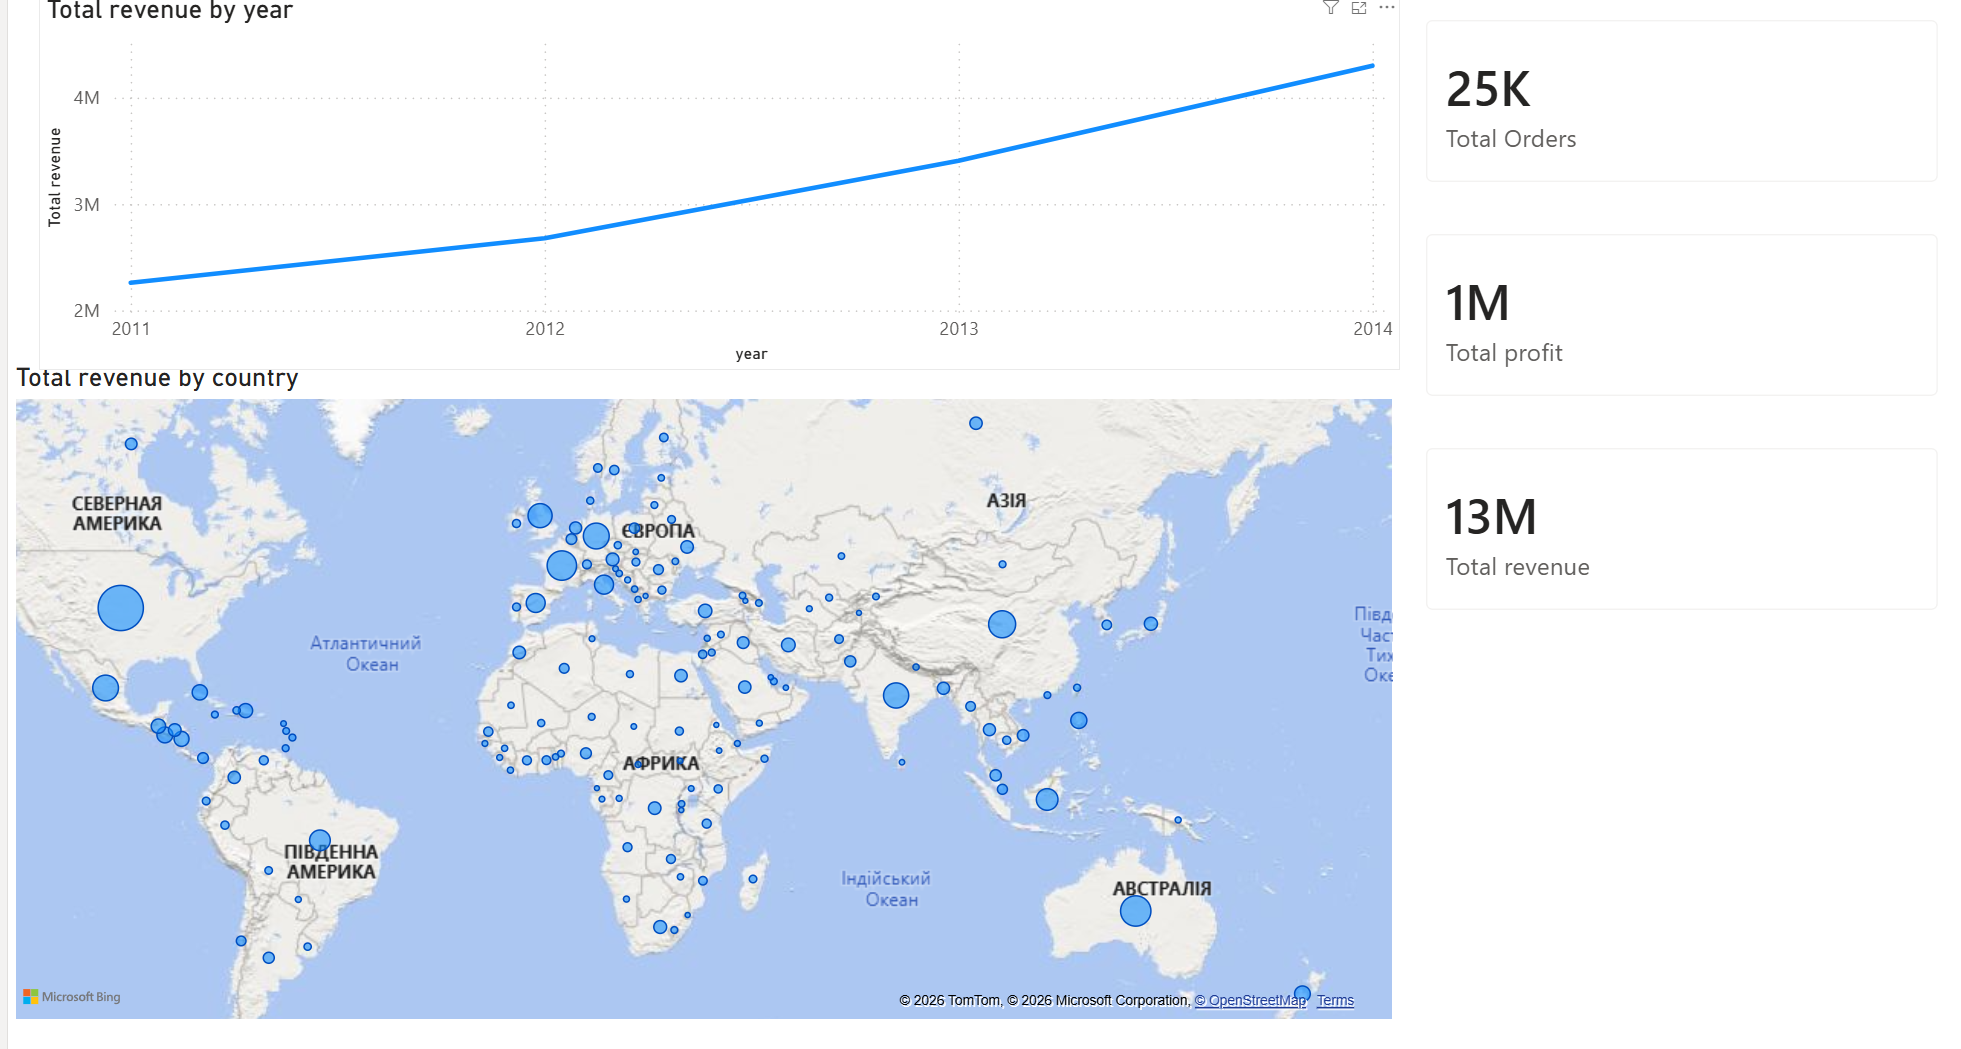